Tidy Data Project 

In this project, I will explore the Olympic Medalists of different sports across gender. I load the "olympics_08_medalists.csv" dataset. Because the data is not tidy, I begin by tidying the data and fixing some of the conjoined variables. After the data is cleaned, I begin with visualizations to explore types of medals and medals by gender. Finally, I aggregate a pivot table by gender and medal counts. This gives a clear indication of medals by sport and gender - perhaps the most enlightening part of my project. 

In order to run this project, one must import pandas, matplotlib, and seaborn. I have commented the code in order to allow for the project to be easily followed or replicated. 

In [9]:
import pandas as pd #This is the first package that is necessary to load and run this project

df_medalists = pd.read_csv("olympics_08_medalists.csv") # I am loading the dataset as the df

print("Original (Untidy) Olypmic Medalist Data:") #Quick view of the untidy data
print(df_medalists)


Original (Untidy) Olypmic Medalist Data:
          medalist_name male_archery female_archery male_athletics  \
0       Aaron Armstrong          NaN            NaN           gold   
1         Aaron Peirsol          NaN            NaN            NaN   
2      Abdullo Tangriev          NaN            NaN            NaN   
3     Abeer Abdelrahman          NaN            NaN            NaN   
4               Abhinav          NaN            NaN            NaN   
...                 ...          ...            ...            ...   
1870        Éver Banega          NaN            NaN            NaN   
1871  Ólafur Stefánsson          NaN            NaN            NaN   
1872      Óscar Brayson          NaN            NaN            NaN   
1873   Łukasz Pawłowski          NaN            NaN            NaN   
1874        Živko Gocić          NaN            NaN            NaN   

     female_athletics male_badminton female_badminton male_baseball  \
0                 NaN            NaN           

Because the Untidy Data is difficult to read, we must tidy the data!

In [ ]:
tidy_df = pd.melt(
    df_medalists,
    id_vars=['medalist_name'],  
    var_name='Sport_Gender',  
    value_name='Medal'        
) # This function creates a new df that is tidy by variable, sport_gender, and medal

#It is not helpful for an analysis to have sport and gender conjoined
split_cols = tidy_df['Sport_Gender'].str.split('_', expand=True) #Splits the variable
tidy_df['Gender'] = split_cols[0] #Reassigns gender and sport to their own column
tidy_df['Sport'] = split_cols[1]
tidy_df = tidy_df.drop(columns=['Sport_Gender']) #There is no point in retaining the variable, so I am dropping it
tidy_df = tidy_df.dropna() # This removes the NA rows that results from changing the data from wide to long
# The dropna had one of the greatest effects on the data as it properly restores the number of rows 

# Let us print and see what the tidy data looks like!
print("Tidy Olypmic Medalist Data:")
print(tidy_df) 

Tidy Olypmic Medalist Data:
              medalist_name   Medal Gender                  Sport
177            Bair Badënov  bronze   male                archery
676           Ilario Di Buò  silver   male                archery
682            Im Dong-hyun    gold   male                archery
760               Jiang Lin  bronze   male                archery
920          Lee Chang-hwan    gold   male                archery
...                     ...     ...    ...                    ...
130932        Steeve Guénot    gold   male  greco-roman wrestling
131159  Yannick Szczepaniak  bronze   male  greco-roman wrestling
131162       Yavor Yanakiev  bronze   male  greco-roman wrestling
131200      Yury Patrikeyev  bronze   male  greco-roman wrestling
131234         Zoltán Fodor  silver   male  greco-roman wrestling

[1875 rows x 4 columns]


In [11]:
# Just in case, we want to clean 'Medal' column strings
tidy_df['Medal'] = tidy_df['Medal'].str.replace('Medal: ', '', regex=False)
tidy_df['Medal'] = tidy_df['Medal'].str.strip()

print("Tidy Olypmic Medalist Data:")
print(tidy_df) 

Tidy Olypmic Medalist Data:
              medalist_name   Medal Gender                  Sport
177            Bair Badënov  bronze   male                archery
676           Ilario Di Buò  silver   male                archery
682            Im Dong-hyun    gold   male                archery
760               Jiang Lin  bronze   male                archery
920          Lee Chang-hwan    gold   male                archery
...                     ...     ...    ...                    ...
130932        Steeve Guénot    gold   male  greco-roman wrestling
131159  Yannick Szczepaniak  bronze   male  greco-roman wrestling
131162       Yavor Yanakiev  bronze   male  greco-roman wrestling
131200      Yury Patrikeyev  bronze   male  greco-roman wrestling
131234         Zoltán Fodor  silver   male  greco-roman wrestling

[1875 rows x 4 columns]


After tidying the data, we can start to form some visualizations of the data. We want to consider medal counts and medal counts by sports and gender!

/var/folders/kc/kh6hwryn02g8gdr9whbjhyp00000gn/T/ipykernel_14319/2387838127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tidy_df, x='Medal', palette='Set2') # places medal type as the x value


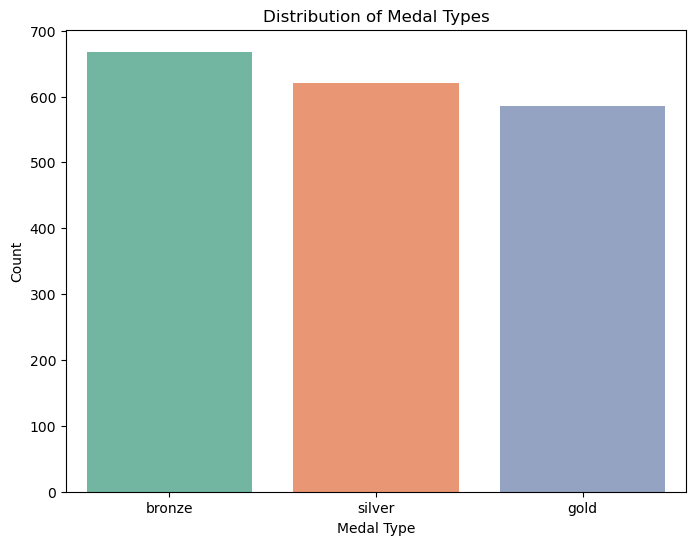

In [13]:
import matplotlib.pyplot as plt #We will need to load both matplotlib and seaborn 
import seaborn as sns

# Count of medals by type
plt.figure(figsize=(8,6))
sns.countplot(data=tidy_df, x='Medal', palette='Set2') # places medal type as the x value
plt.title('Distribution of Medal Types') #Titles our visualization
plt.xlabel('Medal Type') # Labels our X and Y axis
plt.ylabel('Count')
plt.show()

/var/folders/kc/kh6hwryn02g8gdr9whbjhyp00000gn/T/ipykernel_14319/2954188928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=football_df, x='Gender', palette='Set1')


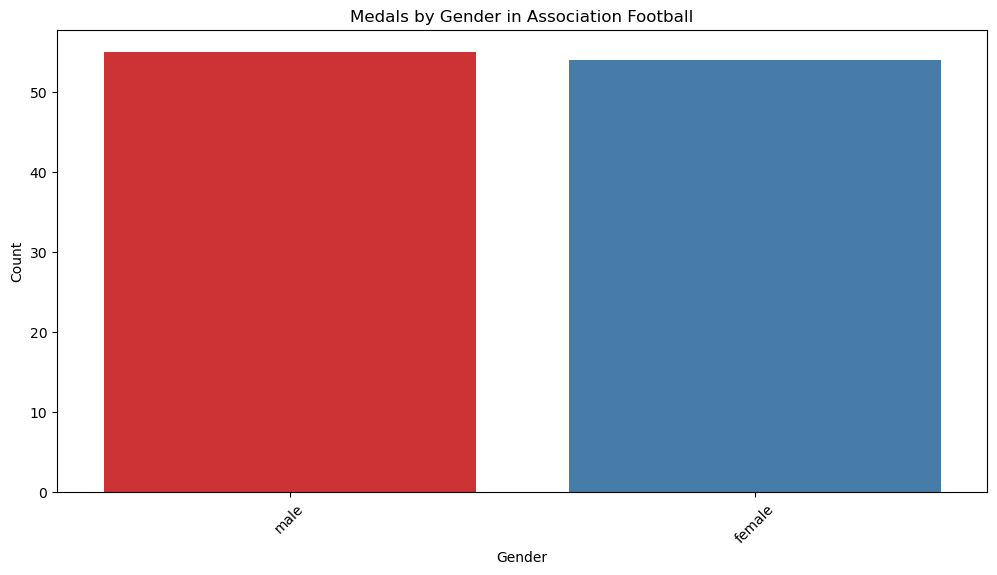

In [14]:
# Count medals for different sports, separated by gender
# Filter data for the sport "association football"
football_df = tidy_df[tidy_df['Sport'] == 'association football']

# Plot the count of medals by gender for "association football"
plt.figure(figsize=(12,6))
sns.countplot(data=football_df, x='Gender', palette='Set1')
plt.title('Medals by Gender in Association Football')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The above graph shows that there is a similar amount of medals among men and women for association football, but let's look at another sport where there might be more of a difference.

/var/folders/kc/kh6hwryn02g8gdr9whbjhyp00000gn/T/ipykernel_14319/422791599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fencing_df, x='Gender', palette='Set1')


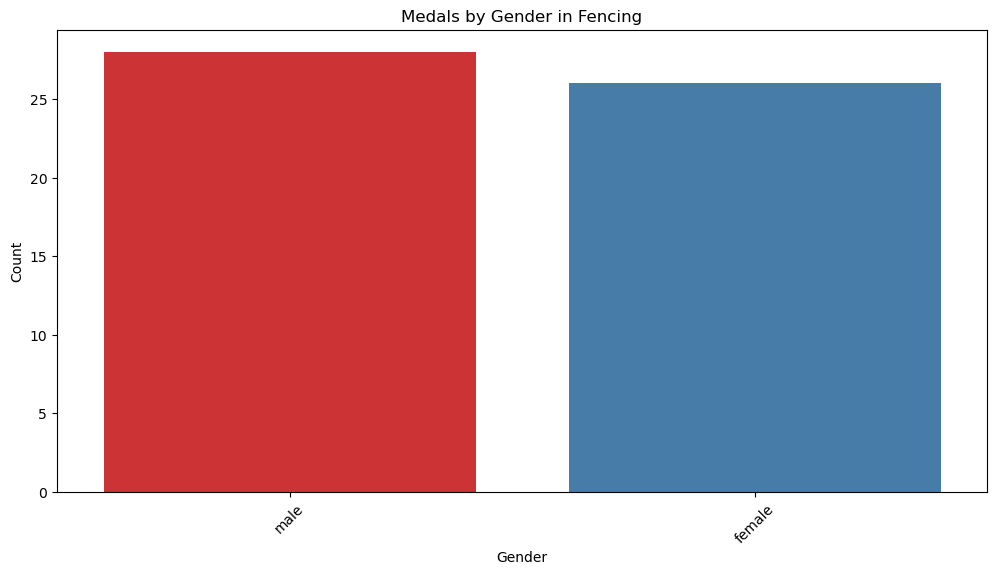

In [ ]:
# The count for sports specific fencing
fencing_df = tidy_df[tidy_df['Sport'] == 'fencing']

# Plot the count of medals by gender for "fencing"
plt.figure(figsize=(12,6))
sns.countplot(data=fencing_df, x='Gender', palette='Set1')
plt.title('Medals by Gender in Fencing')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Let's try one more! 

/var/folders/kc/kh6hwryn02g8gdr9whbjhyp00000gn/T/ipykernel_14319/702492047.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wrestling_df, x='Gender', palette='Set1')


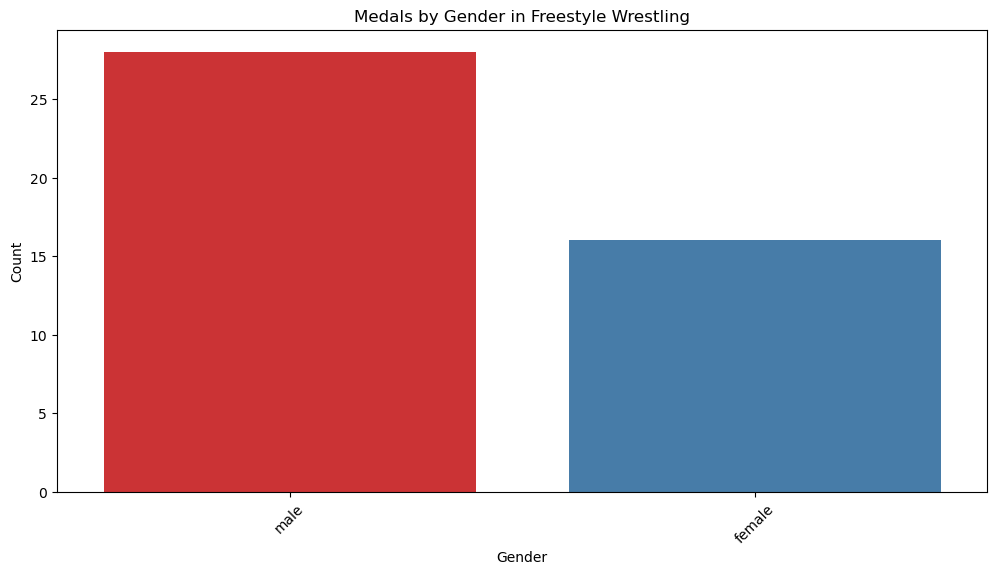

In [17]:
# Filter data for freestyle wrestling
wrestling_df = tidy_df[tidy_df['Sport'] == 'freestyle wrestling']

# Plot the count of medals by gender for freestyle wrestling
plt.figure(figsize=(12,6))
sns.countplot(data=wrestling_df, x='Gender', palette='Set1')
plt.title('Medals by Gender in Freestyle Wrestling')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Finally, we will create a Pivot Table by aggregating counts of medals by sport and gender! This will give us a better picture of the distribution of Olympic medals for different sports and genders.

In [16]:
# Aggregate: count medals for each sport and gender
pivot_table = tidy_df.pivot_table(
    index='Sport',
    columns='Gender',
    values='Medal',
    aggfunc='count', #aggregates the medal count
    fill_value=0
)

print("Medals Count by Sport and Gender:")
print(pivot_table)

Medals Count by Sport and Gender:
Gender                 female  male
Sport                              
archery                     9    11
artistic gymnastics        20    29
association football       54    55
athletics                  81    85
badminton                  10    12
baseball                    0    72
basketball                 36    35
beach volleyball            6     6
bmx                         3     3
boxing                      0    44
canoeing and kayaking      21    53
diving                     13    16
equestrian sport           20    18
fencing                    26    28
field hockey               48    50
freestyle wrestling        16    28
greco-roman wrestling       0    27
handball                   42    43
judo                       28    28
modern pentathlon           2     3
mountain biking             3     3
rhythmic gymnastics        21     0
road bicycle racing         6     5
rowing                     58    83
sailing                    21 